In [165]:
import re
import shutil

import nibabel as nib
import numpy as np
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from time import time

from nilearn.masking import apply_mask, unmask

# Reportlab for pdf 

from reportlab.pdfbase import pdfmetrics
from reportlab.lib.utils import ImageReader
from reportlab.pdfgen import canvas

In [166]:
# Reportlab params for reports

MontSerratBold = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Bold.afm', '../../../utils/fonts/montserrat/Montserrat-Bold.pfb')
MontSerratLight = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Light.afm', '../../../utils/fonts/montserrat/Montserrat-Light.pfb')

# Montserrat Bold

pdfmetrics.registerTypeFace(MontSerratBold)
montserrat_bold_name = 'Montserrat-Bold'

montserrat_bold_font = pdfmetrics.Font('Montserrat-Bold',
                           montserrat_bold_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_bold_font)

# Montserrat Light

pdfmetrics.registerTypeFace(MontSerratLight)
montserrat_light_name = 'Montserrat-Light'

montserrat_light_font = pdfmetrics.Font('Montserrat-Light',
                           montserrat_light_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_light_font)

# Pipeline benchmark

In [205]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/')
mask_roots = np.array([
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-fnirt/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afni/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afniWarp/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-antsAff/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-antsSyN/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/')
])

parameter_file = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/selection_full.csv')
pipe_df = pd.read_csv(parameter_file)
parameter_file = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/selection_slices_filled.csv')
pose_df = pd.read_csv(parameter_file)


pipe_names = [
    'FLIRT',
    'FNIRT',
    'Allineate',
    'Qwarp',
    'ANTs-Aff',
    'ANTs-SyN',
    'MINC',
]

root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dfus.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/')
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/rawdata/')

t_r = 2.4

print(pipe_df.head(5))
print(f'\n\n\n')
print(pose_df.head(5))

We found 212 files
   Unnamed: 0                                          file_name  \
0           0  sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-li...   
1           1  sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-li...   
2           2  sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe...   
3           3  sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-li...   
4           4  sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-li...   

         subject          session  FLIRT  FNIRT  Allineate  Qwarp  ANTs-Aff  \
0  sub-cp230328a     ses-1CPTses1      2      1          2      2         2   
1  sub-cp230328b     ses-1CPTses1      2      0          2      0         0   
2  sub-cp230329a  ses-1MEDISOses1      2      0          2      2         2   
3  sub-cp230329b     ses-1CPTses2      2      1          2      1         2   
4  sub-cp230330a     ses-1CPTses3      2      1          2      2         2   

   ANTs-SyN  MINC  
0         2     2  
1         0     2  
2         2     2  
3         2     2

Best performing Pipeline:


MINC           : 98.00
Allineate      : 90.00
ANTs-SyN       : 88.00
ANTs-Aff       : 88.00
FLIRT          : 88.00
Qwarp          : 50.00
FNIRT          : 10.00


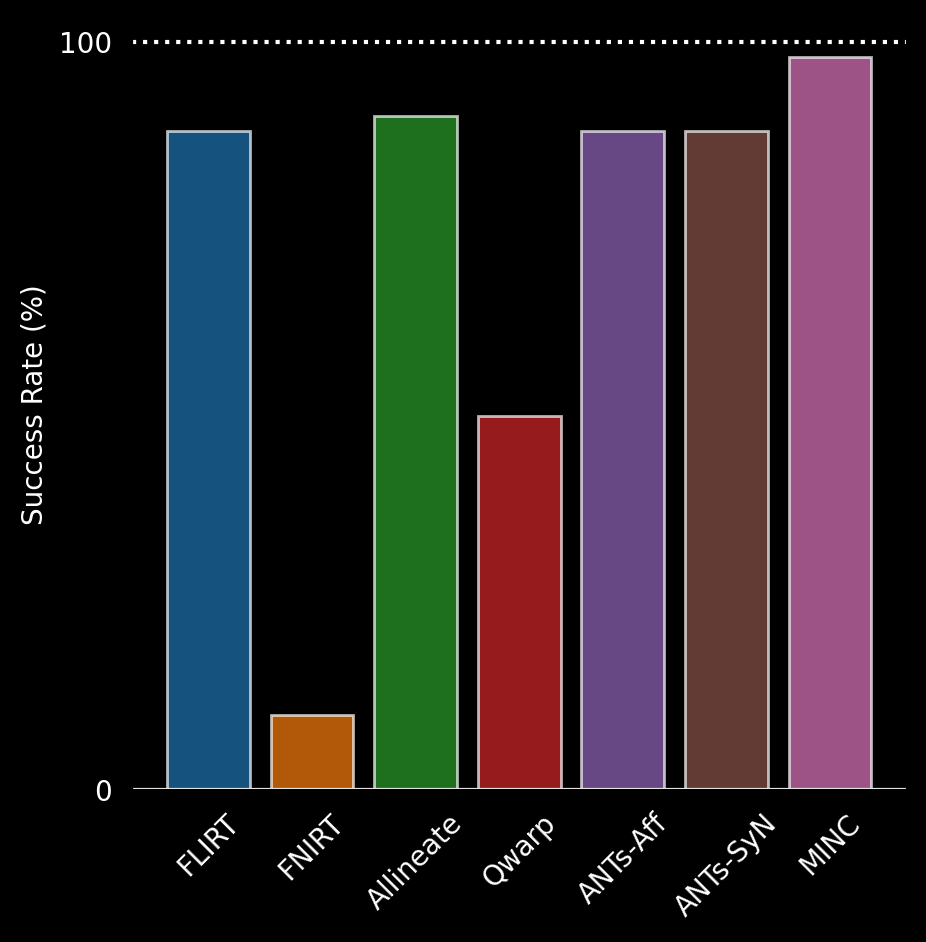

In [195]:
fig, ax = plt.subplots(1,1,figsize = (5,5), dpi = 200, facecolor = 'k')

ax.set(facecolor = 'k')

success_rate = []

for i, pipe_name in enumerate(pipe_names):

    score = 100*(pipe_df[pipe_name] == 2).sum()/len(pipe_df)
    success_rate.append(score)
    
    ax.bar(i, score, alpha = 0.7, edgecolor = 'w')
    
plt.xticks(np.arange(len(pipe_names)), pipe_names, c = 'w', rotation = 45)

plt.axhline(0, c = 'w')
plt.axhline(100, c = 'w', ls = ':')

plt.yticks([0,100], [0,100], color = 'w')
plt.ylabel('Success Rate (%)', color = 'w')

best_performing = np.array(pipe_names)[np.flip(np.argsort(success_rate).squeeze())]

print('Best performing Pipeline:\n\n')

for x,score in zip(best_performing, np.array(success_rate)[np.flip(np.argsort(success_rate).squeeze())]):

    print(f'{x:<15}: {score:.2f}')

In [210]:
file_name = root_dir[48*4+1]
print(file_name.name)


img = nib.load(file_name)

# Extracts file properties

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]

if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    title = f'{subject_name} {session_name} {pose_id} {run_id}'
    regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*{run_id}.*'
else: 
    run_id = None
    title = f'{subject_name} {session_name} {pose_id}'
    regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*'

# Selects best performing algorithm
    
pipe_scores = [pipe_df[(pipe_df['subject'] == subject_name) & (pipe_df['session'] == session_name)][pipe_name].values[0] for pipe_name in pipe_names]

if np.max(pipe_scores) == 0:

    print('No pipeline worked for this file')

else:

    if (pipe_scores == np.max(pipe_scores)).sum() == 1:

        source_idx = np.argmax(pipe_scores).squeeze()

    else:
    
        ind = np.argwhere(pipe_scores == np.max(pipe_scores)).squeeze()
        ind_pipe = np.argmax(np.array(success_rate)[ind]).squeeze()
        source_idx = ind[ind_pipe]

# gets the mask

source_root = mask_roots[source_idx]
mask_name = sorted([x for x in source_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*mask.nii.gz$', x.name)])[0]

print(mask_name)

sub-cp230512a_ses-1HALOses10_task-rest_acq-3Dfus_probe-linear_pose-1_pwd.nii.gz
/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afni/sub-cp230512a/ses-1HALOses10/sub-cp230512a_ses-1HALOses10_acq-3Dscan_probe-linear_proc-registeredAFNIinv_mask.nii.gz


# Skull Stripping

In [196]:
for file_name in tqdm(root_dir):
    
    img = nib.load(file_name)
    
    # Extracts file properties
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        title = f'{subject_name} {session_name} {pose_id} {run_id}'
        regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*{run_id}.*'
    else: 
        run_id = None
        title = f'{subject_name} {session_name} {pose_id}'
        regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*'
    
    # Selects best performing algorithm
        
    pipe_scores = [pipe_df[(pipe_df['subject'] == subject_name) & (pipe_df['session'] == session_name)][pipe_name].values[0] for pipe_name in pipe_names]
    
    if np.max(pipe_scores) == 0:
    
        print('No pipeline worked for this file')
    
    else:
    
        if (pipe_scores == np.max(pipe_scores)).sum() == 1:
    
            source_idx = np.argmax(pipe_scores).squeeze()
    
        else:
        
            ind = np.argwhere(pipe_scores == np.max(pipe_scores)).squeeze()
            ind_pipe = np.argmax(np.array(success_rate)[ind]).squeeze()
            source_idx = ind[ind_pipe]
    
    # gets the mask
    
    source_root = mask_roots[source_idx]
    mask_name = sorted([x for x in source_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*mask.nii.gz$', x.name)])[0]
    slice_id = pose_df[(pose_df['subject'] == subject_name) & (pose_df['session'] == session_name) ][pose_id].values[0]
    
    mask_img = nib.Nifti1Image(
        nib.load(mask_name).get_fdata()[slice_id,:,:][None,:,:],
        affine = img.affine
    )
    
    # Applies mask
    
    skull_stripped_img = unmask(apply_mask(img, mask_img)[125:-125], mask_img)    
    
    # save Image
    
    save_name = save_dir / file_name.parent.parent.parent.name / file_name.parent.parent.name / (file_name.name.split('pwd')[0] + 'proc-skstr_pwd.nii.gz')
    save_name.parent.mkdir(exist_ok = True, parents = True)
    nib.save(
        skull_stripped_img,
        save_name
    )
    
    ######################## Displays skull stripping QC
    
    ############# Slice Mask
    
    fig, ax = plt.subplots(1,1, figsize = (7,5), dpi = 200, facecolor = 'k')
    ax.set(facecolor = 'k')
    
    img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
    
    ax.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2, aspect = 0.1/0.11)
    
    img_2_display = mask_img.get_fdata().squeeze()
    
    ax.imshow(img_2_display, cmap = cc.cm['fire'], vmin = 0, vmax = 2, aspect = 0.1/0.11, alpha = 0.5*img_2_display)
    
    ax.axis('off')
    
    plt.tight_layout()
    
    save_name = save_dir_QC / file_name.parent.parent.parent.name / file_name.parent.parent.name / (file_name.name.split('pwd')[0] + 'proc-skstr_maskOverlay.png')
    plt.savefig(save_name)
    plt.close('all')
    
    
    ############# masked image
    
    fig, ax = plt.subplots(1,1, figsize = (7,5), dpi = 200, facecolor = 'k')
    ax.set(facecolor = 'k')
    
    img_2_display = np.log10(skull_stripped_img.get_fdata().mean(-1).squeeze())
    
    ax.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2, aspect = 0.1/0.11)
    
    ax.axis('off')
    
    plt.tight_layout()
    
    save_name = save_dir_QC / file_name.parent.parent.parent.name / file_name.parent.parent.name / (file_name.name.split('pwd')[0] + 'proc-skstr_maskedImage.png')
    plt.savefig(save_name)
    plt.close('all')

    

  0%|                                        | 0/212 [00:00<?, ?it/s]/tmp/ipykernel_128126/1442085468.py:71: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
/tmp/ipykernel_128126/1442085468.py:93: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(skull_stripped_img.get_fdata().mean(-1).squeeze())
100%|██████████████████████████████| 212/212 [24:14<00:00,  6.86s/it]


## Report

In [198]:
root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/')

root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*pose-0.*maskedImage.*.png$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/')

We found 53 files


In [199]:
w,h = [1500, 700]

# starts

c = canvas.Canvas(str(save_dir_QC / "Slice-wise_skull-stripping_report.pdf"), pagesize = (w,h))

# Front page

c.setFillColorRGB(0,0,0)
c.rect(0,0,w,h,fill=1)

c.setFillColorRGB(1,1,1)
c.setFont("Montserrat-Bold", 30)

title = 'Report - Individual QC - Skull Stripping'
str_w = pdfmetrics.stringWidth(title,"Montserrat-Bold", 30)
c.drawString(w/2-str_w/2, h/2, title)

c.showPage() 

########################### Displays slices - overlay

for file_name in tqdm(root_dir):

    ################################
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    
    
    file_title = ' '.join(file_name.name.split('_proc')[0].split('_'))
    
    ########################### Sets page layout
    
    # set background
    
    c.setFillColorRGB(0,0,0)
    c.rect(0,0,w,h,fill=1)
    
    current_alt = h
    
    # title
    
    c.setFillColorRGB(1,1,1)
    c.setFont("Montserrat-Light", 25)
    c.drawString(10, h-50, file_title)

    
    if 'run' in file_name.name:
    
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*{run_id}.*pose.*proc-skstr_maskOverlay.*.png$', x.name)])
    
    else:
    
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*pose.*proc-skstr_maskOverlay.*.png$', x.name)])
    
    for i,img_name in enumerate(file_dir):
        
        img = ImageReader(img_name)
        img_w, img_h = img.getSize()
        
        if i%2 == 0:
    
            current_x = 50+2*(i//2)*(img_w/4)
            current_alt = h-100
    
        c.drawImage(img, current_x, current_alt-img_h/4, width=img_w/4, height = img_h/4)
        current_alt = current_alt-img_h/4
    
    ########################### Displays slices - masked
    
    if 'run' in file_name.name:
    
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*{run_id}.*pose.*proc-skstr_maskedImage.*.png$', x.name)])
    
    else:
    
        file_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*pose.*proc-skstr_maskedImage.*.png$', x.name)])
    
    for i,img_name in enumerate(file_dir):
        
        img = ImageReader(img_name)
        img_w, img_h = img.getSize()
        
        if i%2 == 0:
    
            current_x = 50+(2*(i//2)+1)*(img_w/4)
            current_alt = h-100
    
        c.drawImage(img, current_x, current_alt-img_h/4, width=img_w/4, height = img_h/4)
        current_alt = current_alt-img_h/4
    
    c.showPage() 
    
c.save()

100%|████████████████████████████████| 53/53 [00:37<00:00,  1.41it/s]


In [145]:
file_id = 202

file_name = root_dir[file_id]
img = nib.load(file_name)

print(f'{i} - {file_name.name}')

# Extracts file properties

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]

if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    title = f'{subject_name} {session_name} {pose_id} {run_id}'
    regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*{run_id}.*'
else: 
    run_id = None
    title = f'{subject_name} {session_name} {pose_id}'
    regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*'

# Selects best performing algorithm

print(title)

pipe_scores = [pipe_df[(pipe_df['subject'] == subject_name) & (pipe_df['session'] == session_name)][pipe_name].values[0] for pipe_name in pipe_names]

if np.max(pipe_scores) == 0:

    print('No pipeline worked for this file')

else:

    if (pipe_scores == np.max(pipe_scores)).sum() == 1:

        source_idx = np.argmax(pipe_scores).squeeze()

    else:
    
        ind = np.argwhere(pipe_scores == np.max(pipe_scores)).squeeze()
        ind_pipe = np.argmax(np.array(success_rate)[ind]).squeeze()
        source_idx = ind[ind_pipe]

print(f'{pipe_names[source_idx]}')

# gets the mask

source_root = mask_roots[source_idx]
mask_name = sorted([x for x in source_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*mask.nii.gz$', x.name)])[0]
slice_id = pose_df[(pose_df['subject'] == subject_name) & (pose_df['session'] == session_name) ][pose_id].values[0]

mask_img = nib.Nifti1Image(
    nib.load(mask_name).get_fdata()[slice_id,:,:][None,:,:],
    affine = img.affine
)

# Applies mask

skull_stripped_img = unmask(apply_mask(img, mask_img)[125:-125], mask_img)    

# save Image

save_name = save_dir / file_name.parent.parent.parent.name / file_name.parent.parent.name / (file_name.name.split('pwd')[0] + 'proc-skstr_pwd.nii.gz')
save_name.parent.mkdir(exist_ok = True, parents = True)
nib.save(
    skull_stripped_img,
    save_name
)

######################## Displays skull stripping QC

############# Slice Mask

fig, ax = plt.subplots(1,1, figsize = (7,5), dpi = 200, facecolor = 'k')
ax.set(facecolor = 'k')

img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())

ax.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2, aspect = 0.1/0.11)

img_2_display = mask_img.get_fdata().squeeze()

ax.imshow(img_2_display, cmap = cc.cm['fire'], vmin = 0, vmax = 2, aspect = 0.1/0.11, alpha = 0.5*img_2_display)

ax.axis('off')

plt.tight_layout()

save_name = save_dir_QC / file_name.parent.parent.parent.name / file_name.parent.parent.name / (file_name.name.split('pwd')[0] + 'proc-skstr_maskOverlay.png')
plt.savefig(save_name)
plt.close('all')


############# masked image

fig, ax = plt.subplots(1,1, figsize = (6,5), dpi = 200, facecolor = 'k')
ax.set(facecolor = 'k')

img_2_display = np.log10(skull_stripped_img.get_fdata().mean(-1).squeeze())

ax.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2, aspect = 0.1/0.11)

ax.axis('off')

plt.tight_layout()

save_name = save_dir_QC / file_name.parent.parent.parent.name / file_name.parent.parent.name / (file_name.name.split('pwd')[0] + 'proc-skstr_maskedImage.png')
plt.savefig(save_name)
plt.close('all')

211 - sub-cp230512c_ses-1CPTses10_task-rest_acq-3Dfus_probe-linear_pose-2_pwd.nii.gz
sub-cp230512c ses-1CPTses10 pose-2
MINC


/tmp/ipykernel_128126/3957770400.py:78: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())
/tmp/ipykernel_128126/3957770400.py:100: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(skull_stripped_img.get_fdata().mean(-1).squeeze())


In [136]:
mask_img.shape

(1, 82, 128)

/tmp/ipykernel_128126/3037021876.py:4: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())


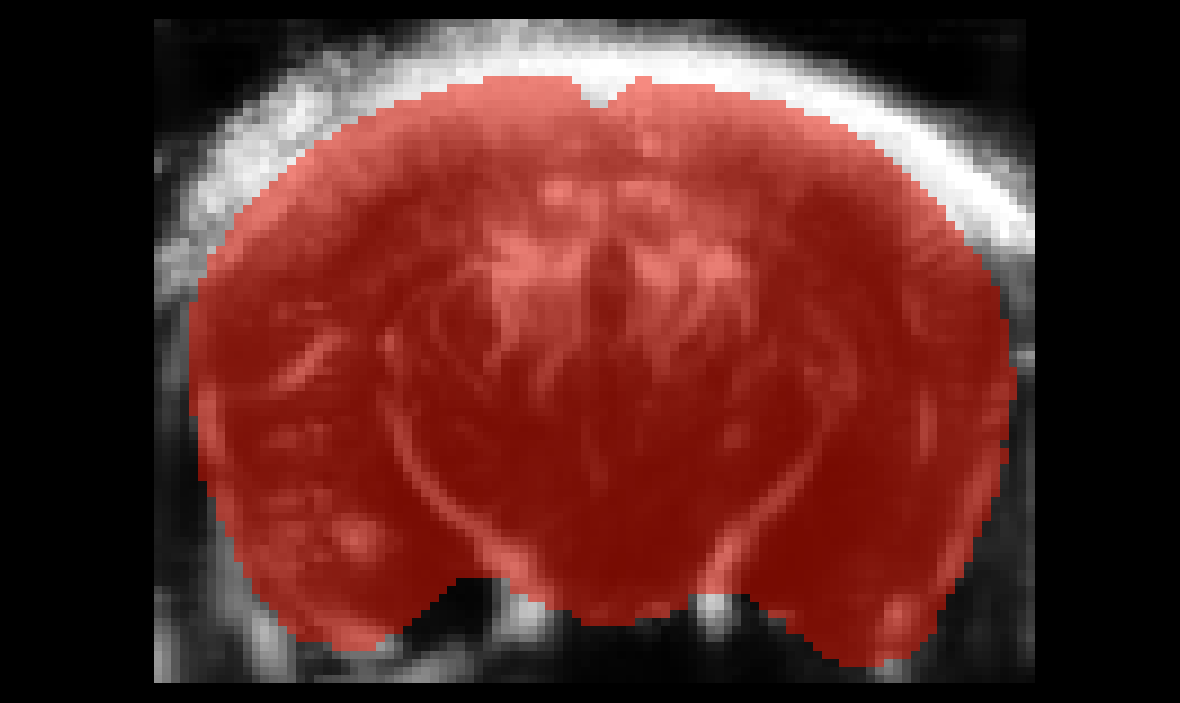

In [139]:
fig, ax = plt.subplots(1,1, figsize = (6,5), dpi = 200, facecolor = 'k')
ax.set(facecolor = 'k')

img_2_display = np.log10(img.get_fdata().mean(-1).squeeze())

ax.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2, aspect = 0.1/0.11)

img_2_display = mask_img.get_fdata().squeeze()

ax.imshow(img_2_display, cmap = cc.cm['fire'], vmin = 0, vmax = 2, aspect = 0.1/0.11, alpha = 0.5*img_2_display)

ax.axis('off')
fig.suptitle()

plt.tight_layout()

/tmp/ipykernel_128126/794050855.py:4: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(skull_stripped_img.get_fdata().mean(-1).squeeze())


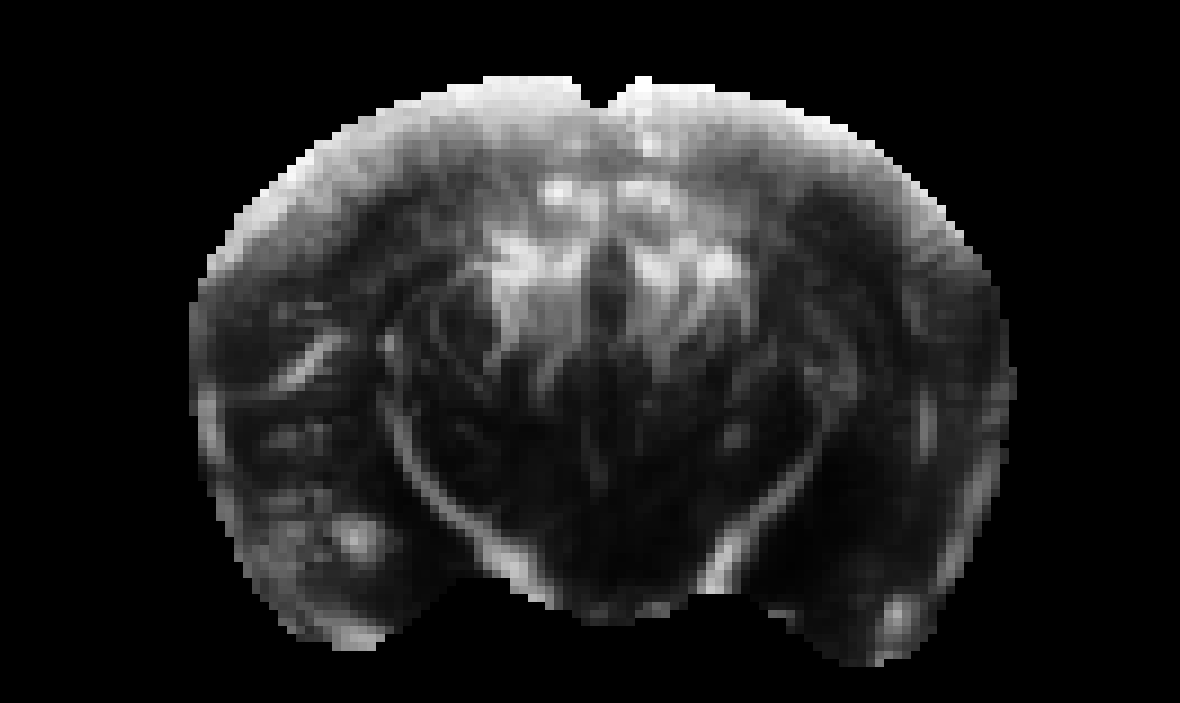

In [140]:
fig, ax = plt.subplots(1,1, figsize = (6,5), dpi = 200, facecolor = 'k')
ax.set(facecolor = 'k')

img_2_display = np.log10(skull_stripped_img.get_fdata().mean(-1).squeeze())

ax.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.7, vmax = 2.2, aspect = 0.1/0.11)

ax.axis('off')

plt.tight_layout()

In [77]:
mask_name = sorted([x for x in source_root])

In [78]:
img.shape

(1, 82, 128, 1500)

In [84]:
pose_df[pose_df['file_name'] == file_name.name]

,Unnamed: 0,file_name,subject,session,pose-0,pose-1,pose-2,pose-3,Problem


In [83]:
pose_df.head(5)

,Unnamed: 0,file_name,subject,session,pose-0,pose-1,pose-2,pose-3,Problem
0,0,sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-li...,sub-cp230328a,ses-1CPTses1,30,40,50,60,0
1,1,sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-li...,sub-cp230328b,ses-1CPTses1,37,47,57,67,0
2,2,sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe...,sub-cp230329a,ses-1MEDISOses1,37,47,57,67,0
3,3,sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-li...,sub-cp230329b,ses-1CPTses2,35,45,55,65,0
4,4,sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-li...,sub-cp230330a,ses-1CPTses3,31,41,51,61,0


In [67]:
pipe_scores = [pose_df[(pose_df['subject'] == subject_name) & (pose_df['session'] == session_name)][pipe_name].values[0] for pipe_name in pipe_names]

if np.max(pipe_scores) == 0:

    print('No pipeline worked for this file')

else:

    ind = np.argwhere(pipe_scores == np.max(pipe_scores)).squeeze()
    ind_pipe = np.argmax(np.array(success_rate)[ind]).squeeze()
    print(pipe_names[ind[ind_pipe]])

MINC
